# ***`INSTALL`***

In [1]:
!pip install pycryptodome

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 27.3 MB/s eta 0:00:00


# ***`IMPORTS`***

In [2]:
import base64
import os
import cv2
import numpy as np
from PIL import Image
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

# ***`ENCRYPTION & DECRYPTION`***

In [3]:
def pad_data(data):
    pad_len = 16 - len(data) % 16
    return data + bytes([pad_len] * pad_len)

def unpad_data(data):
    pad_len = data[-1]
    return data[:-pad_len]


def aes_encrypt(message, key=None):
    if not key:
        key_bytes = get_random_bytes(16)
        key_b64 = base64.b64encode(key_bytes).decode()
        print("Generated random AES key (Base64):", key_b64)
    else:
        key_bytes = key.encode()
        key_b64 = base64.b64encode(key_bytes).decode()

    iv = get_random_bytes(16)
    cipher = AES.new(key_bytes, AES.MODE_CBC, iv)
    padded = pad_data(message.encode())
    encrypted = cipher.encrypt(padded)
    combined = iv + encrypted
    return base64.b64encode(combined).decode(), key_b64


def aes_decrypt(encrypted_message, key_b64):
    key = base64.b64decode(key_b64)
    combined = base64.b64decode(encrypted_message)
    iv, ciphertext = combined[:16], combined[16:]
    cipher = AES.new(key, AES.MODE_CBC, iv)
    decrypted = cipher.decrypt(ciphertext)
    return unpad_data(decrypted).decode()


# Simple XOR as fallback method
def xor_encrypt(message, key):
    return ''.join(chr(ord(c) ^ ord(key[i % len(key)])) for i, c in enumerate(message))

def xor_decrypt(encrypted_message, key):
    return xor_encrypt(encrypted_message, key)

# ***`STEGANOGRAPHY (LSB)`***

In [4]:
def embed_message(image_path, message, output_path):
    img = Image.open(image_path).convert('L')
    data = np.array(img)
    flat = data.flatten()

    binary_msg = ''.join(format(ord(c), '08b') for c in message)
    if len(binary_msg) > len(flat):
        raise ValueError("Message too long to embed in this image.")

    for i in range(len(binary_msg)):
        flat[i] = (flat[i] & 0xFE) | int(binary_msg[i])

    new_data = flat.reshape(data.shape)
    Image.fromarray(new_data.astype(np.uint8)).save(output_path)
    print("Stego image created:", output_path)


def extract_message(image_path, msg_length):
    img = Image.open(image_path).convert('L')
    data = np.array(img).flatten()
    bits = [str(data[i] & 1) for i in range(msg_length * 8)]
    chars = [chr(int(''.join(bits[i:i + 8]), 2)) for i in range(0, len(bits), 8)]
    return ''.join(chars)

# ***`IMAGE QUALITY METRICS`***

In [5]:
def compute_psnr(original_path, modified_path):
    original = cv2.imread(original_path, cv2.IMREAD_GRAYSCALE)
    modified = cv2.imread(modified_path, cv2.IMREAD_GRAYSCALE)
    mse = np.mean((original - modified) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

def compute_ssim(original_path, modified_path):
    original = cv2.imread(original_path, cv2.IMREAD_GRAYSCALE)
    modified = cv2.imread(modified_path, cv2.IMREAD_GRAYSCALE)
    return ssim(original, modified)


# ***`MAIN EXECUTION PIPELINE`***

Step 1: Inputs

In [6]:
message = input("Enter secret message: ")
encryption_type = input("Enter encryption type (aes/xor): ").strip().lower()

Enter secret message: tharun u did it 
Enter encryption type (aes/xor): aes


# **AES mode**

In [7]:
if encryption_type == "aes":
    user_key = input("Enter AES key (press Enter to auto-generate): ").strip()
    ciphertext, final_key = aes_encrypt(message, user_key)
    decrypt_func = lambda ct: aes_decrypt(ct, final_key)
    print("Encryption complete. Use this key for decryption:", final_key)
elif encryption_type == "xor":
    xor_key = input("Enter XOR key: ").strip()
    ciphertext = xor_encrypt(message, xor_key)
    decrypt_func = lambda ct: xor_decrypt(ct, xor_key)

else:
    raise ValueError("Invalid encryption type. Choose 'aes' or 'xor'.")

print("Ciphertext to embed:", ciphertext)

Enter AES key (press Enter to auto-generate): 
Generated random AES key (Base64): RMfANXWCW/w4NjV7o8f9og==
Encryption complete. Use this key for decryption: RMfANXWCW/w4NjV7o8f9og==
Ciphertext to embed: Hw0Eb9g40Z54JAGaCr0NQTyyj7txh1aJ93AuetBIBI6nxZscaYmj7DFE3Bk5lESq


Step 2: Embedding

In [8]:
cover_image_path = input("Enter path to cover image: ")
stego_image_path = input("Enter output path for stego image (include file extension, e.g., .png): ")
embed_message(cover_image_path, ciphertext, stego_image_path)

Enter path to cover image: /content/Screenshot 2025-10-22 164210.png
Enter output path for stego image (include file extension, e.g., .png): /content/output.png
Stego image created: /content/output.png


Step 3: Quality Checking

In [9]:

psnr_val = compute_psnr(cover_image_path, stego_image_path)
ssim_val = compute_ssim(cover_image_path, stego_image_path)
print(f"PSNR: {psnr_val:.2f}")
print(f"SSIM: {ssim_val:.4f}")


PSNR: 44.31
SSIM: 0.9982


Step 4: Entraction and Decryption

In [10]:
msg_length = len(ciphertext)
extracted_cipher = extract_message(stego_image_path, msg_length)
decrypted_text = decrypt_func(extracted_cipher)
print("Decrypted message:", decrypted_text)

Decrypted message: tharun u did it 


# ***`OPTIONAL METRIC VISUALIZATION`***

Stego image created: temp_stego.png
Stego image created: temp_stego.png
Stego image created: temp_stego.png
Stego image created: temp_stego.png
Stego image created: temp_stego.png
Stego image created: temp_stego.png
Stego image created: temp_stego.png
Stego image created: temp_stego.png
Stego image created: temp_stego.png
Stego image created: temp_stego.png
Stego image created: temp_stego.png


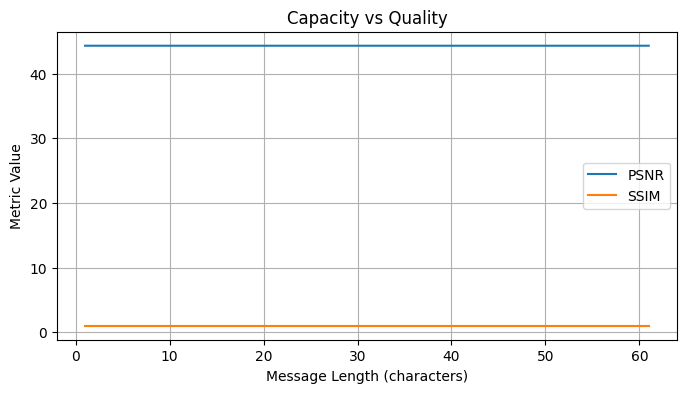

In [12]:
def plot_metrics(lengths, psnr_vals, ssim_vals):
    plt.figure(figsize=(8,4))
    plt.plot(lengths, psnr_vals, label="PSNR")
    plt.plot(lengths, ssim_vals, label="SSIM")
    plt.xlabel("Message Length (characters)")
    plt.ylabel("Metric Value")
    plt.legend()
    plt.title("Capacity vs Quality")
    plt.grid(True)
    plt.show()



lengths, psnr_vals, ssim_vals = [], [], []
msg_len = len(ciphertext)
for l in range(1, msg_len, max(1, msg_len//10)):
    temp_img = "temp_stego.png"
    embed_message(cover_image_path, ciphertext[:l], temp_img)
    lengths.append(l)
    psnr_vals.append(compute_psnr(cover_image_path, temp_img))
    ssim_vals.append(compute_ssim(cover_image_path, temp_img))
    os.remove(temp_img)

plot_metrics(lengths, psnr_vals, ssim_vals)
